# PROG8431 – Solutions to  Highway Congestion​

### Jasper Lim - 9117038 
### John Buni - 9115726
### Eche Oji - 9078881 

Repository link: https://github.com/JohnBuni/Data-Analysis-Project-Group4.git



## Research Question and Project Objectives

### Research Question

What factors contribute to highway congestion in Southern Ontario, and can historical traffic data be used to predict periods of high congestion, or identify alternative routes to aid decongestion?

### Objective of This Analysis

This notebook examines Ontario's 2024 Annual Average Daily Traffic (AADT) dataset to investigate traffic patterns across provincial highway segments and identify factors that may contribute to highway congestion.

Our analysis will:

- Examine traffic-volume distributions using histograms to identify patterns of high traffic demand.
- Assess the normality of traffic-volume data using QQ-plots and the Shapiro–Wilk test.
- Compare traffic-volume variability between selected highway groups using an F-test.
- Compare average traffic volumes between selected highways using a t-test.
- Interpret the statistical findings in relation to highway congestion and traffic patterns in Southern Ontario.

### Relevance to Highway Congestion

Annual Average Daily Traffic (AADT) represents the average number of vehicles traveling along a highway segment per day over a year. It provides an important measure of traffic demand and can help identify highway segments experiencing relatively high traffic volumes.

By examining traffic-volume distributions and comparing highways statistically, this analysis aims to identify patterns that may be relevant to congestion and highlight areas that warrant further investigation.

The findings will contribute to our broader research into highway congestion, traffic prediction, and potential decongestion strategies.

### Dataset Loading and Cleaning

The dataset contains 2024 Annual Average Daily Traffic (AADT) measurements for Ontario provincial highway segments, along with highway identifiers, location descriptions, and segment distances.

We first examine the dataset's structure and missing values. Records missing either segment distance or AADT are excluded from the initial cleaned dataset to support consistent analysis of these variables.

The original dataset is preserved separately so that cleaning decisions can be reviewed. AADT is the main variable of interest because it provides a measure of traffic demand that can help identify patterns relevant to highway congestion.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Load the original Ontario highway traffic dataset.
df_raw = pd.read_excel(
    "data/Provincial Highways Traffic Volumes 2024 AADT Only.xlsx"
)

# Display the original dataset information.
print("Original dataset shape:", df_raw.shape)
print("\nMissing values:")
print(df_raw.isnull().sum())

# Keep records with valid distance and AADT values.
df = df_raw.dropna(
    subset=["Distance (KM)", "2024 AADT"]
).copy()

# Report how many rows were removed.
print("\nCleaned dataset shape:", df.shape)
print("Rows removed:", len(df_raw) - len(df))

# Preview the cleaned dataset.
display(df.head())

Original dataset shape: (2712, 5)

Missing values:
Highway                      304
Location Description From    304
Location Description To      304
Distance (KM)                611
2024 AADT                    902
dtype: int64

Cleaned dataset shape: (1810, 5)
Rows removed: 902


,Highway,Location Description From,Location Description To,Distance (KM),2024 AADT
0,QEW,FORT ERIE-GODERICH ST-PEACE BRIDGE PLAZA,CENTRAL AV IC,0.230,13400.0
1,QEW,CENTRAL AV IC,CONCESSION RD IC-1,0.933,19100.0
2,QEW,CONCESSION RD IC-1,THOMPSON RD IC-2,1.045,18300.0
3,QEW,THOMPSON RD IC-2,GILMORE RD IC-5,2.450,22600.0
4,QEW,GILMORE RD IC-5,BOWEN RD IC-7,2.059,26300.0


## Exploratory Data Analysis: Traffic Volume Distributions

To investigate patterns relevant to highway congestion, we examine the distributions of highway segment distances and 2024 Annual Average Daily Traffic (AADT).

The distance histogram helps describe the physical characteristics of the recorded highway segments, while the AADT histogram shows how traffic demand varies across the highway network.

We also calculate descriptive statistics to identify typical traffic volumes, variability, and potential skewness. Segments with relatively high AADT may warrant further investigation because they experience greater average traffic demand.

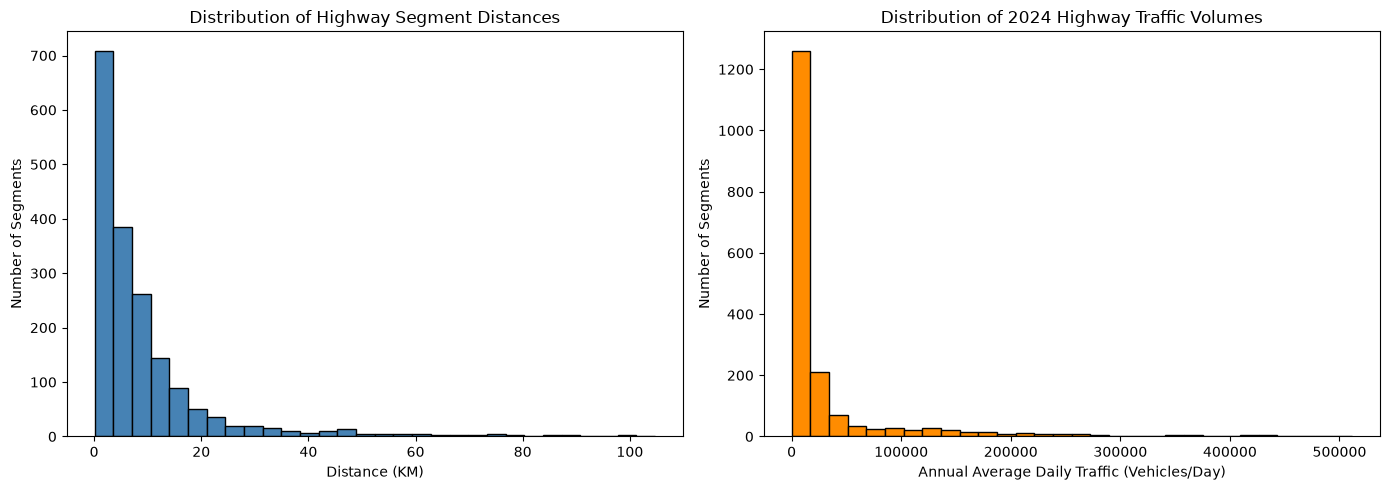

In [3]:
# Create histograms for highway segment distance and traffic volume.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram 1: Highway segment distance
axes[0].hist(
    df["Distance (KM)"],
    bins=30,
    color="steelblue",
    edgecolor="black"
)
axes[0].set_title("Distribution of Highway Segment Distances")
axes[0].set_xlabel("Distance (KM)")
axes[0].set_ylabel("Number of Segments")

# Histogram 2: Annual Average Daily Traffic
axes[1].hist(
    df["2024 AADT"],
    bins=30,
    color="darkorange",
    edgecolor="black"
)
axes[1].set_title("Distribution of 2024 Highway Traffic Volumes")
axes[1].set_xlabel("Annual Average Daily Traffic (Vehicles/Day)")
axes[1].set_ylabel("Number of Segments")

plt.tight_layout()
plt.show()

In [4]:
# Summarize segment distance and annual average daily traffic.
display(df[["Distance (KM)", "2024 AADT"]].describe().round(2))

print(f"Mean AADT: {df['2024 AADT'].mean():,.2f}")
print(f"Median AADT: {df['2024 AADT'].median():,.2f}")


,Distance (KM),2024 AADT
count,1810.00,1810.00
mean,9.14,31808.32
std,12.47,66712.33
min,0.10,10.00
25%,2.14,2012.50
50%,5.11,7350.00
75%,10.60,23500.00
max,104.69,511400.00


Mean AADT: 31,808.32
Median AADT: 7,350.00


## Normality Assessment of Highway Traffic Volumes

We assess whether Annual Average Daily Traffic (AADT) values approximately follow a normal distribution.

A QQ-plot visually compares the observed traffic volumes against a theoretical normal distribution. The Shapiro–Wilk test provides a statistical assessment of normality.

Understanding the distribution of traffic volumes helps us determine which statistical methods are appropriate for comparing highway traffic patterns.

The null hypothesis states that the AADT is normally distributed.

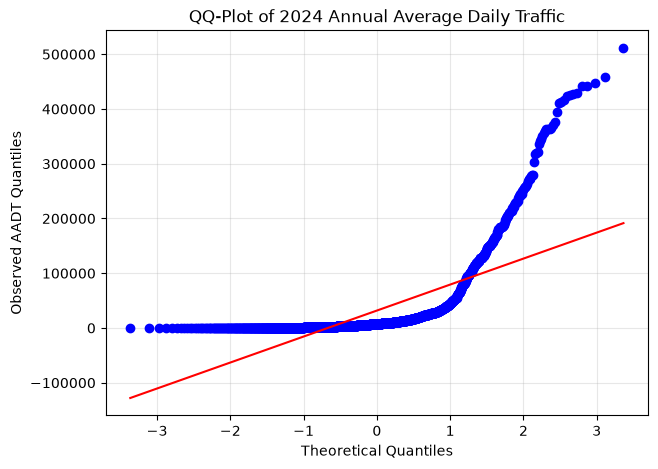

Shapiro-Wilk statistic: 0.5055
P-value: 2.13582e-57
Reject the null hypothesis: AADT is not normally distributed.


In [9]:
# Select traffic volume as the variable for normality testing.
aadt = df["2024 AADT"].dropna()

# Create a QQ-plot.
plt.figure(figsize=(7, 5))
stats.probplot(aadt, dist="norm", plot=plt)

plt.title("QQ-Plot of 2024 Annual Average Daily Traffic")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Observed AADT Quantiles")
plt.grid(alpha=0.3)
plt.show()

# Perform the Shapiro-Wilk normality test.
shapiro_stat, shapiro_p = stats.shapiro(aadt)

print(f"Shapiro-Wilk statistic: {shapiro_stat:.4f}")
print(f"P-value: {shapiro_p:.6g}")

# Interpret the test using a 5% significance level.
alpha = 0.05

if shapiro_p < alpha:
    print("Reject the null hypothesis: AADT is not normally distributed.")
else:
    print("Fail to reject the null hypothesis of normality.")

### Interpretation of Normality Results

The Shapiro–Wilk test produced a statistic of 0.5055 and a p-value of 2.13582 × 10⁻⁵⁷, far below the 0.05 threshold. We therefore reject the hypothesis that 2024 AADT follows a normal distribution. The QQ-plot shows pronounced upward curvature, particularly at higher quantiles, where observed traffic volumes depart substantially from the normal reference line. This pattern suggests a right-skewed distribution, with a relatively small number of highway segments carrying exceptionally high traffic volumes. These results describe differences in traffic demand across Ontario highways and caution against assuming normally distributed observations in subsequent statistical comparisons between the selected highway groups in Ontario.

## Equality of Variances: Highway 401 vs. Highway 400

Highways 401 and 400 are major Southern Ontario routes with sufficient segment observations for comparison. We use an F-test to investigate whether Annual Average Daily Traffic (AADT) variability differs between Highway 401 and Highway 400.

Comparing traffic-volume variability across highway segments helps us understand differences in traffic demand along two major Southern Ontario highways.

The null hypothesis states that the population variances are equal, while the alternative hypothesis states that they differ.

In [7]:
# Select AADT observations for Highway 401 and Highway 400.
highway_401 = df.loc[
    df["Highway"].astype(str) == "401", "2024 AADT"
].dropna()

highway_400 = df.loc[
    df["Highway"].astype(str) == "400", "2024 AADT"
].dropna()

# Calculate sample variances.
variance_401 = highway_401.var(ddof=1)
variance_400 = highway_400.var(ddof=1)

# Calculate the F-statistic.
f_statistic = variance_401 / variance_400

# Degrees of freedom.
df1 = len(highway_401) - 1
df2 = len(highway_400) - 1

# Two-sided F-test p-value.
p_lower = stats.f.cdf(f_statistic, df1, df2)
p_upper = stats.f.sf(f_statistic, df1, df2)
p_value = min(1.0, 2 * min(p_lower, p_upper))

print(f"Highway 401 observations: {len(highway_401)}")
print(f"Highway 400 observations: {len(highway_400)}")
print(f"Highway 401 variance: {variance_401:.2f}")
print(f"Highway 400 variance: {variance_400:.2f}")
print(f"F-statistic: {f_statistic:.4f}")
print(f"P-value: {p_value:.6g}")

if p_value < 0.05:
    print("Reject H0: The AADT variances differ significantly.")
else:
    print("Fail to reject H0: No significant variance difference detected.")

Highway 401 observations: 159
Highway 400 observations: 49
Highway 401 variance: 15790703964.65
Highway 400 variance: 5203377312.93
F-statistic: 3.0347
P-value: 2.40188e-05
Reject H0: The AADT variances differ significantly.


### Interpretation of F-Test Results

The F-test yielded a statistic of 3.0347 and a p-value of 0.000024, below the 0.05 threshold. We reject equal variances: sampled Highway 401 segments show greater AADT variability than Highway 400 segments. Because the classical F-test assumes normally distributed, independent observations, this finding should be interpreted cautiously in this analysis.

## Comparison of Mean Traffic Volumes: Highway 401 vs. Highway 400

We use Welch's two-sample t-test to determine whether average Annual Average Daily Traffic (AADT) differs significantly between Highway 401 and Highway 400.

Welch's t-test is appropriate for comparing groups with unequal variances, as indicated by our earlier F-test.

The null hypothesis states that both highways have equal population mean AADT, while the alternative hypothesis states that their population means differ.

In [8]:
# Calculate descriptive statistics for each highway.
mean_401 = highway_401.mean()
mean_400 = highway_400.mean()

print(f"Highway 401 mean AADT: {mean_401:,.2f}")
print(f"Highway 400 mean AADT: {mean_400:,.2f}")
print(f"Difference in means: {mean_401 - mean_400:,.2f}")

# Perform Welch's two-sample t-test.
t_statistic, t_p_value = stats.ttest_ind(
    highway_401,
    highway_400,
    equal_var=False
)

print(f"\nT-statistic: {t_statistic:.4f}")
print(f"P-value: {t_p_value:.6g}")

# Interpret the result.
alpha = 0.05

if t_p_value < alpha:
    print("Reject H0: The mean AADT values differ significantly.")
else:
    print("Fail to reject H0: No significant difference in mean AADT detected.")

Highway 401 mean AADT: 120,432.08
Highway 400 mean AADT: 75,265.31
Difference in means: 45,166.77

T-statistic: 3.1507
P-value: 0.00198657
Reject H0: The mean AADT values differ significantly.


### Interpretation of T-Test Results

Welch's t-test yielded a statistic of 3.1507 and a p-value of 0.00199, below 0.05. We reject equal mean AADT values. Highway 401 averaged approximately 45,167 more vehicles per day per sampled segment than Highway 400. This indicates higher average traffic demand, not necessarily greater congestion or longer actual travel delays.

## Findings and Conclusion

### Summary of Statistical Findings

This analysis examined Ontario's 2024 Annual Average Daily Traffic (AADT) data to investigate traffic-volume patterns relevant to highway congestion in Southern Ontario.

Our statistical analysis produced the following findings:

- **Traffic-volume distribution:** The Shapiro–Wilk test returned a statistic of 0.5055 and a p-value of 2.13582 × 10⁻⁵⁷, indicating that AADT values are not normally distributed.
- **Traffic-volume variability:** The F-test produced a statistic of 3.0347 and a p-value of 0.000024, suggesting that AADT varies more widely across sampled Highway 401 segments than Highway 400 segments.
- **Average traffic demand:** Welch's t-test produced a statistic of 3.1507 and a p-value of 0.00199. Highway 401 recorded an average AADT of 120,432 vehicles, compared with 75,265 for Highway 400, a difference of approximately 45,167 vehicles per day.

### Connection to the Research Question

Our findings demonstrate that traffic demand is not evenly distributed across Ontario's provincial highway network. The comparison between Highways 401 and 400 identifies substantial differences in average traffic volumes and variability, suggesting that certain highways and segments experience greater traffic demand.

These differences are relevant to understanding potential contributors to congestion. Highway segments carrying higher traffic volumes may face greater pressure on available road capacity, particularly during peak travel periods.

However, AADT represents annual average traffic volume rather than direct measurements of congestion. The results identify patterns worth investigating but cannot independently establish when congestion occurs or whether an alternative route would reduce travel times.

### Conclusion and Future Research

This project provides an initial statistical foundation for investigating highway congestion in Southern Ontario using historical traffic data.

The findings highlight Highway 401 as an important area for further investigation because its sampled segments show higher average traffic demand and greater variation in traffic volumes than Highway 400.

Future analysis could combine historical AADT measurements with hourly traffic counts, vehicle speeds, road capacity, and travel-time data. These additional variables would support more precise identification of congestion periods, development of predictive models, and evaluation of potential alternative routes.

Overall, this analysis demonstrates how statistical methods can identify meaningful differences in highway traffic demand and help guide further congestion research.